In [1]:
import pandas as pd
df = pd.read_csv('creditcard.csv')

In [2]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.count()

Time      284807
V1        284807
V2        284807
V3        284807
V4        284807
V5        284807
V6        284807
V7        284807
V8        284807
V9        284807
V10       284807
V11       284807
V12       284807
V13       284807
V14       284807
V15       284807
V16       284807
V17       284807
V18       284807
V19       284807
V20       284807
V21       284807
V22       284807
V23       284807
V24       284807
V25       284807
V26       284807
V27       284807
V28       284807
Amount    284807
Class     284807
dtype: int64

In [4]:
df.groupby('Class').size()

Class
0    284315
1       492
dtype: int64

In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

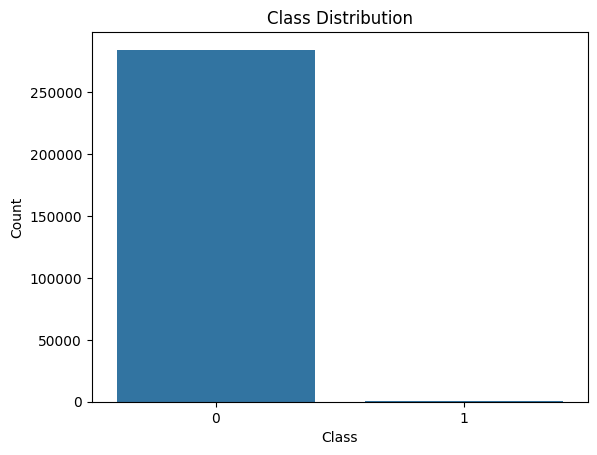

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=df)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [7]:
df=df.drop('Time', axis=1)
legit = df[df.Class==0]

In [8]:
fraud= df[df.Class==1]

In [9]:
legit.Amount.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [10]:
fraud.Amount.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [11]:
unbalanced=df

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [13]:
unbalanced_para=unbalanced.iloc[: , :-1]
unbalanced_res=unbalanced.iloc[:,-1]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    unbalanced_para,
    unbalanced_res,
    test_size=0.2,
    random_state=42,
    stratify=unbalanced_res
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [15]:
scaler=MinMaxScaler()
X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test['Amount'] = scaler.transform(X_test[['Amount']])
model=LogisticRegression(max_iter=1000)
model2=RandomForestClassifier(n_estimators=100,
    class_weight='balanced',
    random_state=42)
model.fit(X_train,y_train)
model2.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
y_pred=model.predict(X_test)
y_pred2=model2.predict(X_test)
from sklearn.metrics import recall_score
print(recall_score(y_test,y_pred))
print(recall_score(y_test,y_pred2))
#This is because the data is highly imbalanced, the model is learning mostly legit , many frauds are going undetected

0.6326530612244898
0.7551020408163265


In [20]:
X2_train,X2_test,y2_train,y2_test=X_train,X_test,y_train,y_test
df2=pd.concat([X2_train,y2_train], axis=1)

In [21]:
from sklearn.svm import SVC
svm_model=SVC()
legit2=df2[df2.Class==0]
fraud2= df2[df2.Class==1]
legit_sample=legit2.sample(4*len(fraud2), random_state=42)
Z_train = pd.concat([legit_sample,fraud2])
Z_train.groupby('Class').size()
X2_train=Z_train.iloc[: , :-1]
y2_train=Z_train.iloc[:,-1]

In [22]:
X2_train['Amount'] = scaler.fit_transform(X2_train[['Amount']])
X2_test['Amount'] = scaler.transform(X2_test[['Amount']])
model.fit(X2_train,y2_train)
model2.fit(X2_train,y2_train)
svm_model.fit(X2_train,y2_train)
y2_pred=model.predict(X2_test)
y2_pred2=model2.predict(X2_test)
y2_pred3=svm_model.predict(X2_test)
print(recall_score(y2_test,y2_pred))
print(recall_score(y2_test,y2_pred2))
print(recall_score(y2_test,y2_pred3))

0.8979591836734694
0.8877551020408163
0.8877551020408163


In [23]:
from sklearn.metrics import precision_score

print(precision_score(y2_test, y2_pred))
print(precision_score(y2_test, y2_pred2))
print(precision_score(y2_test, y2_pred3))

0.12772133526850507
0.2507204610951009
0.18550106609808104


In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [31]:
ann = Sequential()

ann.add(Dense(units=16, activation='relu', input_shape=(X2_train.shape[1],)))
ann.add(Dense(units=1, activation='sigmoid'))  # binary classification

ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ann.fit(X2_train, y2_train, epochs=50, batch_size=32)

Epoch 1/50


C:\Users\Anurag Parasar Mund\anaconda3\envs\myenv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7076 - loss: 0.5618   
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9183 - loss: 0.3629 
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9619 - loss: 0.2677  
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9665 - loss: 0.2089  
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9690 - loss: 0.1710  
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9690 - loss: 0.1458  
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9701 - loss: 0.1286  
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 967us/step - accuracy: 0.9706 - loss: 0.1163
Epoch 9/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9711 - loss: 0.1071  
Epoch 10/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9716 - loss: 0.1000  
Epoch 11/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9726 - loss: 0.0945  
Epoch 12/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 

In [35]:
y_pred_ann = (ann.predict(X2_test) > 0.5).astype(int).flatten()
print(recall_score(y2_test,y_pred_ann))
print(precision_score(y2_test, y_pred_ann))

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 592us/step
0.8877551020408163
0.14821124361158433


C:\Users\Anurag Parasar Mund\AppData\Local\Temp\ipykernel_23580\1737462140.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


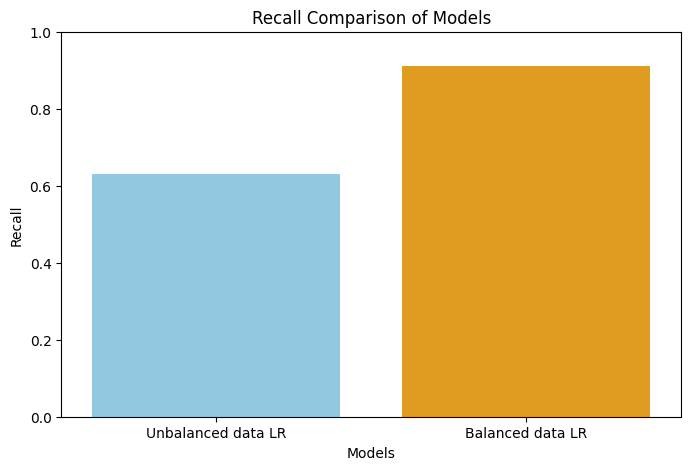

In [108]:
models = [
    "Unbalanced data LR",
    "Balanced data LR",
]

recalls = [
    0.63,
    0.91,
]
colors = [
    "skyblue",   # Unbalanced LR
    "orange",    # Balanced LR
]

df_plot = pd.DataFrame({
    "Model": models,
    "Recall": recalls
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=df_plot,
    x="Model",
    y="Recall",
    palette=colors
)

plt.ylim(0,1)
plt.title("Recall Comparison of Models")
plt.ylabel("Recall")
plt.xlabel("Models")
plt.show()

C:\Users\Anurag Parasar Mund\AppData\Local\Temp\ipykernel_23580\889361449.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


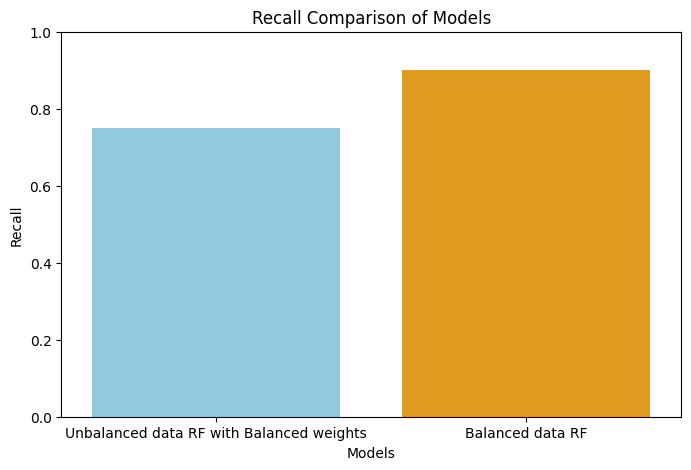

In [109]:
models = [
    "Unbalanced data RF with Balanced weights",
    "Balanced data RF",
]

recalls = [
    0.75,
    0.90,
]
colors = [
    "skyblue",   # Unbalanced LR
    "orange",    # Balanced LR
]

df_plot = pd.DataFrame({
    "Model": models,
    "Recall": recalls
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=df_plot,
    x="Model",
    y="Recall",
    palette=colors
)

plt.ylim(0,1)
plt.title("Recall Comparison of Models")
plt.ylabel("Recall")
plt.xlabel("Models")
plt.show()

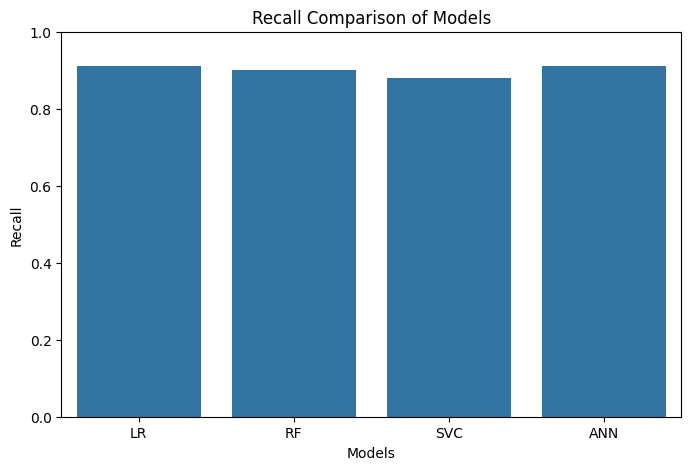

In [33]:
models = [
    "LR",
    "RF",
    "SVC",
    "ANN",
]

recalls = [
    0.91,
    0.90,
    0.88,
    0.91
    
]

df_plot = pd.DataFrame({
    "Model": models,
    "Recall": recalls
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=df_plot,
    x="Model",
    y="Recall",
)

plt.ylim(0,1)
plt.title("Recall Comparison of Models")
plt.ylabel("Recall")
plt.xlabel("Models")
plt.show()

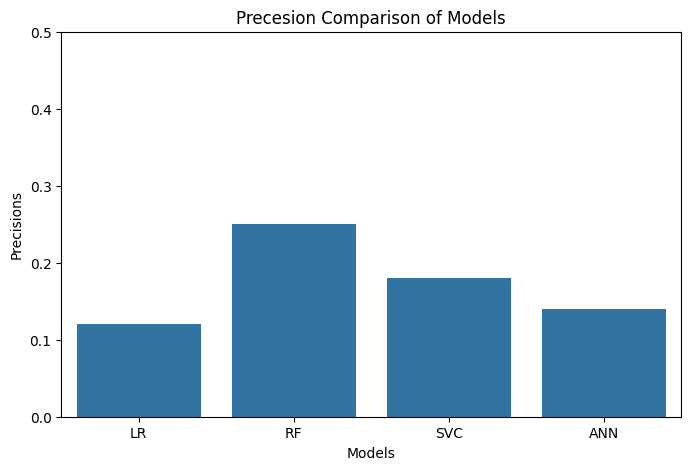

In [36]:
models = [
    "LR",
    "RF",
    "SVC",
    "ANN",
]

recalls = [
    0.12,
    0.25,
    0.18,
    0.14
    
]

df_plot = pd.DataFrame({
    "Model": models,
    "Precisions": recalls
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=df_plot,
    x="Model",
    y="Precisions",
)

plt.ylim(0,.5)
plt.title("Precesion Comparison of Models")
plt.ylabel("Precisions")
plt.xlabel("Models")
plt.show()